In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files


In [4]:
!pip install -q imbalanced-learn
!pip install -q kaggle

In [5]:
import json, os

token = {"username": "UmerBhatti2003", "key": "API Token"}

os.makedirs("/root/.config/kaggle", exist_ok=True)
with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump(token, f)

os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("Done")

Done


In [6]:
!kaggle datasets files bertvankeulen/cicids-2017

name                     size  creationDate                
------------------  ---------  --------------------------  
friday.csv          199983721  2024-07-17 16:35:02.855000  
friday_plus.csv     244226354  2024-07-17 16:35:04.465000  
monday.csv          146143601  2024-07-17 16:35:03.891000  
monday_plus.csv     174470811  2024-07-17 16:35:03.067000  
thursday.csv        132500204  2024-07-17 16:35:02.967000  
thursday_plus.csv   161084118  2024-07-17 16:35:03.521000  
tuesday.csv         125393583  2024-07-17 16:35:04.015000  
tuesday_plus.csv    149301905  2024-07-17 16:35:03.637000  
wednesday.csv       206984560  2024-07-17 16:35:03.825000  
wednesday_plus.csv  246436566  2024-07-17 16:35:06.273000  


In [7]:
!kaggle datasets download -d bertvankeulen/cicids-2017 -f "friday.csv" -p /content/data/


Dataset URL: https://www.kaggle.com/datasets/bertvankeulen/cicids-2017
License(s): apache-2.0
100% 54.4M/54.4M [00:00<00:00, 117MB/s] 



In [8]:
!unzip /content/data/friday.csv.zip -d /content/data/

Archive:  /content/data/friday.csv.zip
  inflating: /content/data/friday.csv  


In [9]:
!ls /content/data/

friday.csv  friday.csv.zip


Preprocessing Script


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

CSV_PATH = "/content/data/friday.csv"

print("Loading dataset...")
df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"\nLabel distribution:\n{df['Label'].value_counts()}")

print("\nCleaning data...")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before - after} rows (NaN / duplicates)")

df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['Label'])

print(f"\nBinary label counts:\n{df['binary_label'].value_counts()}")
print(f"Class names: {list(le.classes_)}")

DROP_COLS = ['Label', 'binary_label', 'encoded_label']
X = df.drop(columns=DROP_COLS)
y = df['binary_label']
X = X.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Attack %: {y.mean()*100:.1f}%")

os.makedirs("/content/output", exist_ok=True)
np.save("/content/output/X_scaled.npy", X_scaled)
np.save("/content/output/y.npy", y.values)

with open("/content/output/feature_names.txt", "w") as f:
    f.write("\n".join(X.columns.tolist()))

print("\nDone. Saved to /content/output/")

Loading dataset...
Shape: (547557, 89)

Label distribution:
Label
BENIGN                288544
Portscan              159066
DDoS                   95144
Botnet - Attempted      4067
Botnet                   736
Name: count, dtype: int64

Cleaning data...
Removed 2 rows (NaN / duplicates)

Binary label counts:
binary_label
0    288542
1    259013
Name: count, dtype: int64
Class names: ['BENIGN', 'Botnet', 'Botnet - Attempted', 'DDoS', 'Portscan']

Feature matrix shape: (547555, 87)
Attack %: 47.3%

Done. Saved to /content/output/


Random Forest Classifier

In [12]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib
import os

# ── 1. Load preprocessed data ────────────────────────────────────────────────
print("Loading data...")
X = np.load("/content/output/X_scaled.npy")
y = np.load("/content/output/y.npy")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# ── 2. Train/test split (80% train, 20% test) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps attack % the same in both splits
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# ── 3. Train the Random Forest ───────────────────────────────────────────────
print("\nTraining Random Forest...")
print("(This takes 1-3 minutes on Colab — you'll see Done when finished)")

rf = RandomForestClassifier(
    n_estimators=100,     # 100 decision trees
    max_depth=20,         # prevents overfitting
    n_jobs=-1,            # use all available CPU cores
    random_state=42,
    verbose=1             # shows progress
)

rf.fit(X_train, y_train)

# ── 4. Quick sanity check ────────────────────────────────────────────────────
train_score = rf.score(X_train, y_train)
test_score  = rf.score(X_test,  y_test)

print(f"\nTraining accuracy : {train_score*100:.2f}%")
print(f"Testing accuracy  : {test_score*100:.2f}%")

# ── 5. Save everything for Phase 3 ───────────────────────────────────────────
os.makedirs("/content/output", exist_ok=True)
joblib.dump(rf, "/content/output/random_forest.pkl")
np.save("/content/output/X_test.npy", X_test)
np.save("/content/output/y_test.npy", y_test)

print("\nDone. Model saved to /content/output/random_forest.pkl")

Loading data...
X shape: (547555, 87), y shape: (547555,)
Training samples : 438044
Testing samples  : 109511

Training Random Forest...
(This takes 1-3 minutes on Colab — you'll see Done when finished)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   30.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s



Training accuracy : 100.00%
Testing accuracy  : 100.00%

Done. Model saved to /content/output/random_forest.pkl


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished


Evaluate Model

In [13]:
import numpy as np
import joblib
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# ── 1. Load model and test data ──────────────────────────────────────────────
print("Loading model and test data...")
rf      = joblib.load("/content/output/random_forest.pkl")
X_test  = np.load("/content/output/X_test.npy")
y_test  = np.load("/content/output/y_test.npy")

# ── 2. Make predictions ──────────────────────────────────────────────────────
print("Running predictions...")
y_pred = rf.predict(X_test)

# ── 3. Overall metrics ───────────────────────────────────────────────────────
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\n════════════════════════════════")
print("       OVERALL METRICS          ")
print("════════════════════════════════")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print("════════════════════════════════")

# ── 4. Per-class breakdown ───────────────────────────────────────────────────
print("\nPer-class breakdown:")
print(classification_report(
    y_test, y_pred,
    target_names=["BENIGN", "ATTACK"]
))

# ── 5. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("════════════════════════════════")
print("       CONFUSION MATRIX         ")
print("════════════════════════════════")
print(f"  True Negatives  (correct BENIGN) : {tn:,}")
print(f"  True Positives  (caught attacks) : {tp:,}")
print(f"  False Positives (false alarms)   : {fp:,}")
print(f"  False Negatives (missed attacks) : {fn:,}")
print("════════════════════════════════")

# ── 6. Save predictions for Phase 5 visualisation ───────────────────────────
np.save("/content/output/y_pred.npy", y_pred)
print("\nDone. Predictions saved for Phase 5.")

Loading model and test data...
Running predictions...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished



════════════════════════════════
       OVERALL METRICS          
════════════════════════════════
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%
════════════════════════════════

Per-class breakdown:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     57708
      ATTACK       1.00      1.00      1.00     51803

    accuracy                           1.00    109511
   macro avg       1.00      1.00      1.00    109511
weighted avg       1.00      1.00      1.00    109511

════════════════════════════════
       CONFUSION MATRIX         
════════════════════════════════
  True Negatives  (correct BENIGN) : 57,707
  True Positives  (caught attacks) : 51,801
  False Positives (false alarms)   : 1
  False Negatives (missed attacks) : 2
════════════════════════════════

Done. Predictions saved for Phase 5.


Monitoring and Alert System

In [14]:
import numpy as np
import joblib
import pandas as pd
from datetime import datetime
import time
import os

# ── 1. Load model and feature names ─────────────────────────────────────────
print("Loading model...")
rf = joblib.load("/content/output/random_forest.pkl")

with open("/content/output/feature_names.txt") as f:
    feature_names = f.read().splitlines()

# ── 2. Load a sample of real data to simulate incoming traffic ───────────────
print("Preparing traffic simulator...")
X_test = np.load("/content/output/X_test.npy")
y_test = np.load("/content/output/y_test.npy")

# Shuffle to mix benign and attack traffic
np.random.seed(99)
idx = np.random.permutation(len(X_test))
X_test = X_test[idx]
y_test = y_test[idx]

# ── 3. Alert log ─────────────────────────────────────────────────────────────
os.makedirs("/content/output", exist_ok=True)
alert_log = []

# ── 4. Monitoring function ───────────────────────────────────────────────────
def monitor_traffic(X_stream, y_true, batch_size=50, n_batches=10):
    """
    Simulates real-time monitoring by processing traffic in batches.
    batch_size : number of network flows per batch (like per-second snapshots)
    n_batches  : how many rounds to monitor
    """
    total_flows    = 0
    total_alerts   = 0
    total_missed   = 0
    total_fp       = 0

    print("\n" + "═"*55)
    print("   INTRUSION DETECTION SYSTEM — LIVE MONITOR")
    print("═"*55)

    for batch_num in range(n_batches):
        # Grab next batch of traffic
        start = batch_num * batch_size
        end   = start + batch_size
        X_batch = X_stream[start:end]
        y_batch = y_true[start:end]

        # Run through model
        predictions  = rf.predict(X_batch)
        timestamp    = datetime.now().strftime("%H:%M:%S")

        # Count outcomes
        attacks_in_batch  = int(y_batch.sum())
        alerts_raised     = int(predictions.sum())
        true_positives    = int(((predictions == 1) & (y_batch == 1)).sum())
        false_positives   = int(((predictions == 1) & (y_batch == 0)).sum())
        missed            = int(((predictions == 0) & (y_batch == 1)).sum())

        total_flows  += batch_size
        total_alerts += alerts_raised
        total_missed += missed
        total_fp     += false_positives

        # Print batch summary
        status = "ALERT" if alerts_raised > 0 else "CLEAR"
        marker = "!!!" if alerts_raised > 0 else "   "

        print(f"\n[{timestamp}] Batch {batch_num+1:02d} — {status} {marker}")
        print(f"  Flows analysed : {batch_size}")
        print(f"  Attacks in batch : {attacks_in_batch}")
        print(f"  Alerts raised  : {alerts_raised}")
        print(f"  True positives : {true_positives}")
        print(f"  False positives: {false_positives}")
        print(f"  Missed attacks : {missed}")

        # Log alerts
        if alerts_raised > 0:
            alert_log.append({
                "timestamp"      : timestamp,
                "batch"          : batch_num + 1,
                "flows_analysed" : batch_size,
                "alerts_raised"  : alerts_raised,
                "true_positives" : true_positives,
                "false_positives": false_positives,
                "missed"         : missed
            })

        time.sleep(0.5)  # simulate real-time delay between batches

    # ── 5. Session summary ───────────────────────────────────────────────────
    print("\n" + "═"*55)
    print("   SESSION SUMMARY")
    print("═"*55)
    print(f"  Total flows monitored : {total_flows}")
    print(f"  Total alerts raised   : {total_alerts}")
    print(f"  Total missed attacks  : {total_missed}")
    print(f"  Total false alarms    : {total_fp}")
    detection_rate = ((total_alerts - total_fp) / max(1, total_alerts)) * 100
    print(f"  Detection rate        : {detection_rate:.1f}%")
    print("═"*55)

    # ── 6. Save alert log ────────────────────────────────────────────────────
    if alert_log:
        df_log = pd.DataFrame(alert_log)
        df_log.to_csv("/content/output/alert_log.csv", index=False)
        print(f"\n  Alert log saved → /content/output/alert_log.csv")
    else:
        print("\n  No alerts raised during this session.")

# ── 7. Run the monitor ───────────────────────────────────────────────────────
monitor_traffic(X_test, y_test, batch_size=50, n_batches=10)

Loading model...
Preparing traffic simulator...

═══════════════════════════════════════════════════════
   INTRUSION DETECTION SYSTEM — LIVE MONITOR
═══════════════════════════════════════════════════════

[17:48:51] Batch 01 — ALERT !!!
  Flows analysed : 50
  Attacks in batch : 22
  Alerts raised  : 22
  True positives : 22
  False positives: 0
  Missed attacks : 0


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished



[17:48:51] Batch 02 — ALERT !!!
  Flows analysed : 50
  Attacks in batch : 22
  Alerts raised  : 22
  True positives : 22
  False positives: 0
  Missed attacks : 0


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished



[17:48:52] Batch 03 — ALERT !!!
  Flows analysed : 50
  Attacks in batch : 25
  Alerts raised  : 25
  True positives : 25
  False positives: 0
  Missed attacks : 0


...


[17:48:54] Batch 08 — ALERT !!!
  Flows analysed : 50
  Attacks in batch : 24
  Alerts raised  : 24
  True positives : 24
  False positives: 0
  Missed attacks : 0


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished



[17:48:55] Batch 09 — ALERT !!!
  Flows analysed : 50
  Attacks in batch : 19
  Alerts raised  : 19
  True positives : 19
  False positives: 0
  Missed attacks : 0


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished



[17:48:55] Batch 10 — ALERT !!!
  Flows analysed : 50
  Attacks in batch : 19
  Alerts raised  : 19
  True positives : 19
  False positives: 0
  Missed attacks : 0

═══════════════════════════════════════════════════════
   SESSION SUMMARY
═══════════════════════════════════════════════════════
  Total flows monitored : 500
  Total alerts raised   : 213
  Total missed attacks  : 0
  Total false alarms    : 0
  Detection rate        : 100.0%
═══════════════════════════════════════════════════════

  Alert log saved → /content/output/alert_log.csv


Visualisation

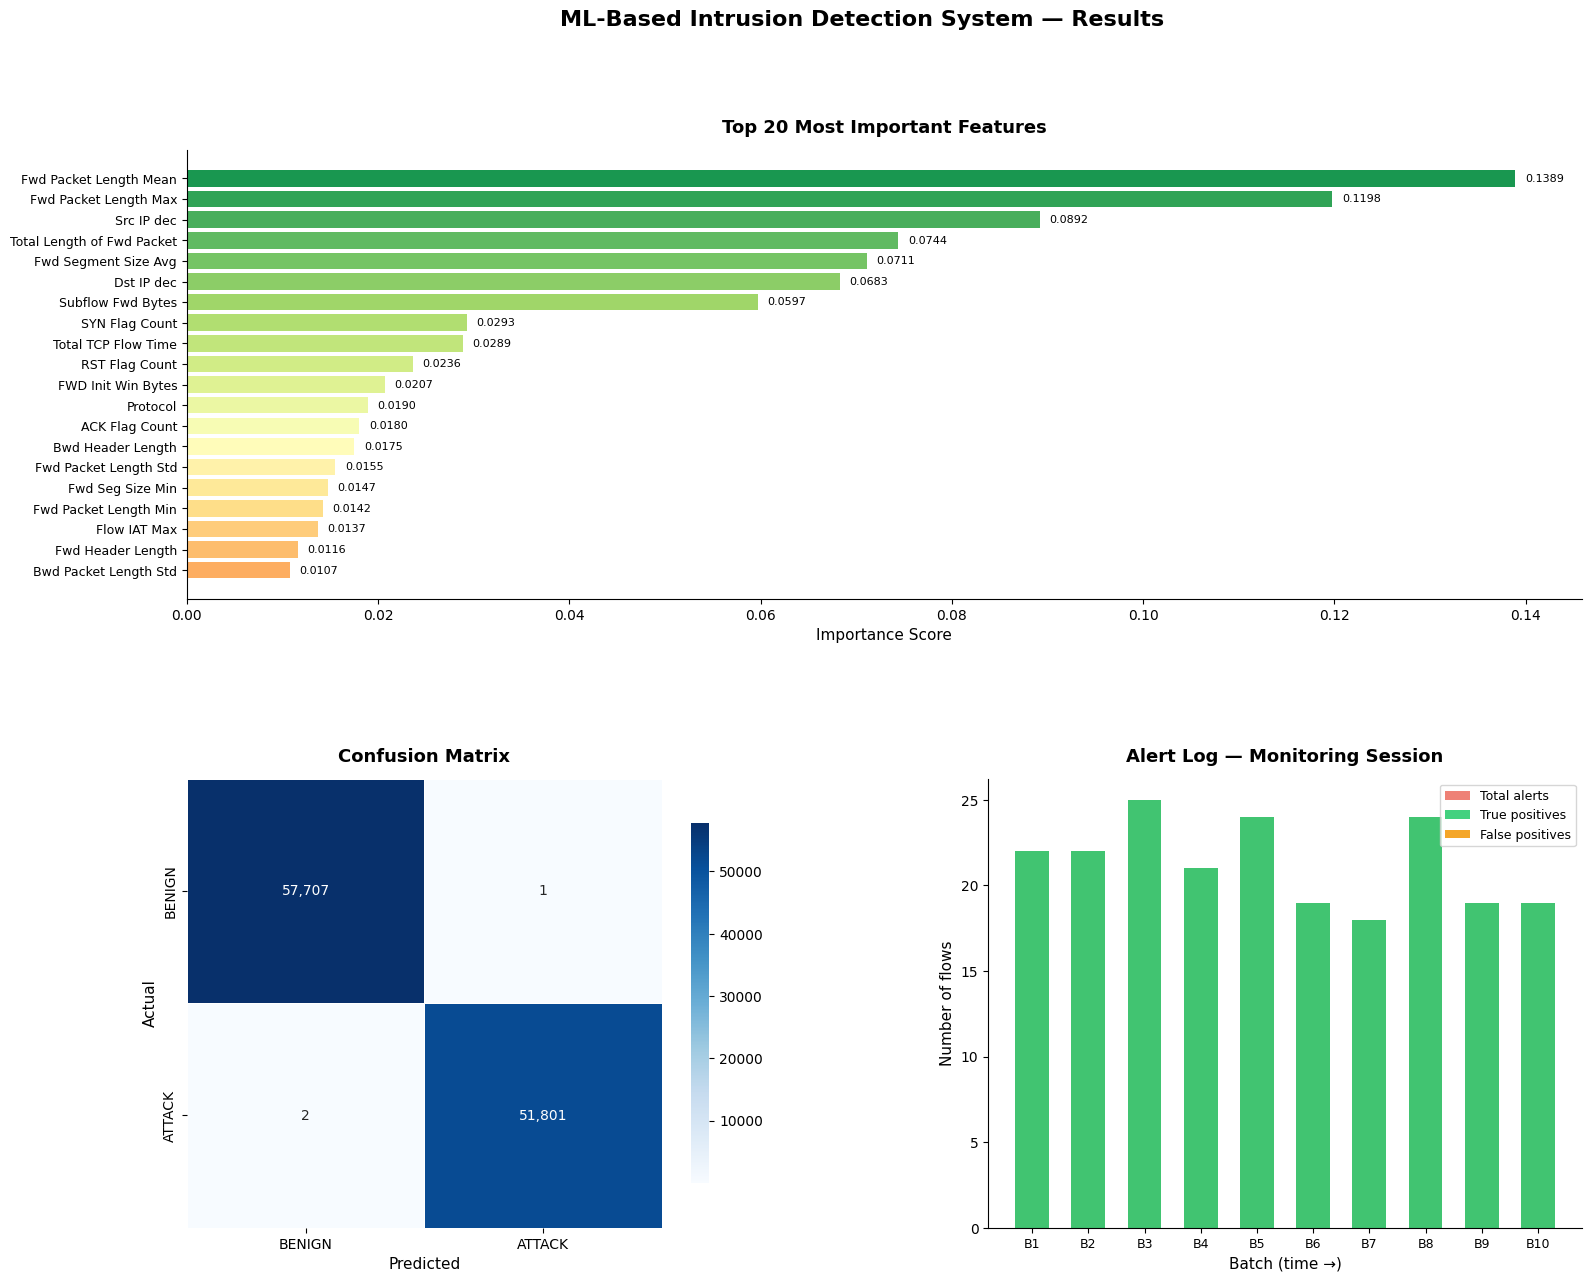


Saved → /content/output/ids_results.png


In [15]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

# ── Load everything ──────────────────────────────────────────────────────────
rf      = joblib.load("/content/output/random_forest.pkl")
X_test  = np.load("/content/output/X_test.npy")
y_test  = np.load("/content/output/y_test.npy")
y_pred  = np.load("/content/output/y_pred.npy")

with open("/content/output/feature_names.txt") as f:
    feature_names = f.read().splitlines()

alert_log = pd.read_csv("/content/output/alert_log.csv")

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("ML-Based Intrusion Detection System — Results",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])   # feature importance — full width top
ax2 = fig.add_subplot(gs[1, 0])   # confusion matrix — bottom left
ax3 = fig.add_subplot(gs[1, 1])   # alert log — bottom right

# ── Chart 1: Top 20 Feature Importances ─────────────────────────────────────
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1][:20]
top_features = [feature_names[i] for i in indices]
top_values   = importances[indices]

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))[::-1]
bars = ax1.barh(range(20), top_values[::-1], color=colors[::-1])
ax1.set_yticks(range(20))
ax1.set_yticklabels(top_features[::-1], fontsize=9)
ax1.set_xlabel("Importance Score", fontsize=11)
ax1.set_title("Top 20 Most Important Features", fontsize=13, fontweight="bold", pad=12)
ax1.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, top_values[::-1]):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8)

# ── Chart 2: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt=",", cmap="Blues",
    xticklabels=["BENIGN", "ATTACK"],
    yticklabels=["BENIGN", "ATTACK"],
    ax=ax2, linewidths=0.5, cbar_kws={"shrink": 0.8}
)
ax2.set_xlabel("Predicted", fontsize=11)
ax2.set_ylabel("Actual", fontsize=11)
ax2.set_title("Confusion Matrix", fontsize=13, fontweight="bold", pad=12)

# ── Chart 3: Alert Log Timeline ──────────────────────────────────────────────
batches = alert_log["batch"]
alerts  = alert_log["alerts_raised"]
tp      = alert_log["true_positives"]
fp      = alert_log["false_positives"]

ax3.bar(batches, alerts, color="#e74c3c", alpha=0.7, label="Total alerts", width=0.6)
ax3.bar(batches, tp,     color="#2ecc71", alpha=0.9, label="True positives", width=0.6)
ax3.bar(batches, fp,     color="#f39c12", alpha=0.9, label="False positives", width=0.6)

ax3.set_xlabel("Batch (time →)", fontsize=11)
ax3.set_ylabel("Number of flows", fontsize=11)
ax3.set_title("Alert Log — Monitoring Session", fontsize=13, fontweight="bold", pad=12)
ax3.set_xticks(batches)
ax3.set_xticklabels([f"B{b}" for b in batches], fontsize=9)
ax3.legend(fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

# ── Save ─────────────────────────────────────────────────────────────────────
os.makedirs("/content/output", exist_ok=True)
plt.savefig("/content/output/ids_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → /content/output/ids_results.png")

